In [3]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl")
using .TensorBinding
import TensorCrossInterpolation as TCI

## Four-panel NH figure

NH 1D tight-binding chain with spatially modulated loss γ(i) = γ₀(1 − cos(2π·2i/N)), γ₀ = 0.1, N = 128 sites, PBC.

| Panel | Content | Method |
|-------|---------|--------|
| (a) | Spectral weight in the complex energy plane | NH KPM on modulated-loss chain H_mod |
| (b) | Many-body diagonal density ⟨i\|ρ(t)\|i⟩ | NH RK4 on half-filled Fermi sea under H_mod |
| (c) | Spatial density profiles at selected times | Slices of (b) |
| (d) | Single-particle amplitude Re⟨i\|ψ(t)⟩ | TDVP, two-site superposition at zero-loss center |

Each panel is computed in its own cell below.

In [4]:
# Shared setup: Hamiltonians.
# Variables are suffixed _fig to be independent of the exploratory cells above.
L_fig  = 7      # 2^7 = 128 sites
t_fig  = 1.0    # nearest-neighbour hopping
γ0_fig = 1.0    # loss amplitude

H_herm_fig = TensorBinding.get_Hamiltonian("chain_1d", t_fig; L=L_fig, boundary=:periodic)
TensorBinding._ensure_scale!(H_herm_fig)

H_mod_fig = deepcopy(H_herm_fig)
TensorBinding.add_loss!(H_mod_fig,
    n -> γ0_fig - γ0_fig * cos(2 * 2π * (n-1) / H_mod_fig.N); maxdim=100)

println(H_mod_fig)
println("MPO bond dim: ", ITensorMPS.maxlinkdim(H_mod_fig.mpo))

TBHamiltonian | L=7, N=128, scale=auto, maxlinkdim=5 | geometry: 128 sites, 1D | no Tn cache
MPO bond dim: 5


In [7]:
# Shared setup: initial density matrix and NH RK4 evolution.
ρ0_fig = TensorBinding.mcweeny_purify(H_herm_fig;
    maxiters=30, maxdim=50, cutoff=1e-8, verbose=false)
println("Tr(ρ₀) = ", real(tr(ρ0_fig)), "  (expected ~", H_herm_fig.N ÷ 2, ")")

dt_rk4     = 0.125
nsteps_rk4 = 120   # T = 15

states_rk4 = TensorBinding.evolve_rk4_dm_nh(
    _ -> H_mod_fig.mpo, ρ0_fig, nsteps_rk4, Float64(dt_rk4);
    maxdim=60, cutoff=1e-10, truncate_intermediates=true, verbose=false)
println("RK4 done: ", length(states_rk4), " snapshots")

Tr(ρ₀) = 64.99996508238135  (expected ~64)
RK4 done: 121 snapshots


In [5]:
# Panel (a): spectral weight in the complex energy plane via NH KPM.
Ncheb_pa     = 10
scale_pa     = 4.5
nx_pa, ny_pa = 40, 40

xgrid_pa, ygrid_pa, Z_pa = TensorBinding.nh_spectrum_grid(
    H_mod_fig, (-2.0, 2.0), nx_pa, (-2.0, 0.0), ny_pa, Ncheb_pa;
    scale = scale_pa, convention = :z_minus_H, mode=:stochastic,
    maxdim = 100, cutoff = 1e-8, verbose=true)

println("(a) grid: ", size(Z_pa))

nh_spectrum_grid [mode=:stochastic]: 40×40=1600 points, Ncheb=20
  col  1/40  Re(z)=-2.0 ...  done
  col  2/40  Re(z)=-1.8974 ...  done
  col  3/40  Re(z)=-1.7949 ...  done
  col  4/40  Re(z)=-1.6923 ...  done
  col  5/40  Re(z)=-1.5897 ...  done
  col  6/40  Re(z)=-1.4872 ...  done
  col  7/40  Re(z)=-1.3846 ...  done
  col  8/40  Re(z)=-1.2821 ...  done
  col  9/40  Re(z)=-1.1795 ...  done
  col 10/40  Re(z)=-1.0769 ...  done
  col 11/40  Re(z)=-0.9744 ...  done
  col 12/40  Re(z)=-0.8718 ...  done
  col 13/40  Re(z)=-0.7692 ...  done
  col 14/40  Re(z)=-0.6667 ...  done
  col 15/40  Re(z)=-0.5641 ...  done
  col 16/40  Re(z)=-0.4615 ...  done
  col 17/40  Re(z)=-0.359 ...  done
  col 18/40  Re(z)=-0.2564 ...  done
  col 19/40  Re(z)=-0.1538 ...  done
  col 20/40  Re(z)=-0.0513 ...  done
  col 21/40  Re(z)=0.0513 ...  done
  col 22/40  Re(z)=0.1538 ...  done
  col 23/40  Re(z)=0.2564 ...  done
  col 24/40  Re(z)=0.359 ...  done
  col 25/40  Re(z)=0.4615 ...  done
  col 26/40  Re(z)=0

In [8]:
# Panel (b): many-body diagonal density ⟨i|ρ(t)|i⟩ from the RK4 trajectory.
N_p      = H_mod_fig.N
times_pb = collect(range(0.0, nsteps_rk4 * dt_rk4, length = nsteps_rk4 + 1))

density_pb = zeros(N_p, length(states_rk4))
for (j, ρ) in enumerate(states_rk4)
    diag = TensorBinding.extract_diagonal_to_mps(ρ)
    density_pb[:, j] = [real(TensorBinding.eval_mps(diag, i)) for i in 0:N_p-1]
end

println("(b) density_pb ", size(density_pb), "  t ∈ [0, $(times_pb[end])]")

(b) density_pb (128, 121)  t ∈ [0, 15.0]


In [9]:
# Panel (c): spatial density profiles (slices of density_pb at selected times).
slice_times = [0.0, 4.0, 9.0, 14.0]
slice_idx   = [findfirst(times_pb .>= t) for t in slice_times]

println("(c) slice times: ", [round(times_pb[i], digits=2) for i in slice_idx])

(c) slice times: [0.0, 4.0, 9.0, 14.0]


In [10]:
# Panel (d): three TDVP runs — no-loss, low-loss center, high-loss center.
# Low-loss center: i=64 (γ=0).  High-loss center: i=32 (γ=2γ₀).
site_pd_lo = H_mod_fig.N ÷ 2   # 64
site_pd_hi = H_mod_fig.N ÷ 4   # 32

ψ0_pd_lo = normalize(+(
    TensorBinding.binary_to_MPS(site_pd_lo - 1, L_fig, H_mod_fig.sites),
    TensorBinding.binary_to_MPS(site_pd_lo,     L_fig, H_mod_fig.sites);
    cutoff = 1e-12))

ψ0_pd_hi = normalize(+(
    TensorBinding.binary_to_MPS(site_pd_hi - 1, L_fig, H_mod_fig.sites),
    TensorBinding.binary_to_MPS(site_pd_hi,     L_fig, H_mod_fig.sites);
    cutoff = 1e-12))

dt_pd     = 0.025
nsteps_pd = 500   # T = 12.5

states_pd_noloss = TensorBinding.evolve_with_tdvp(
    H_herm_fig, ψ0_pd_lo, nsteps_pd, Float64(dt_pd);
    normalize_each_step = false, maxdim = 80, cutoff = 1e-10, outputlevel = 0)

states_pd_lo = TensorBinding.evolve_with_tdvp(
    H_mod_fig, ψ0_pd_lo, nsteps_pd, Float64(dt_pd);
    normalize_each_step = false, maxdim = 80, cutoff = 1e-10, outputlevel = 0)

states_pd_hi = TensorBinding.evolve_with_tdvp(
    H_mod_fig, ψ0_pd_hi, nsteps_pd, Float64(dt_pd);
    normalize_each_step = false, maxdim = 80, cutoff = 1e-10, outputlevel = 0)

times_pd = collect(range(0.0, nsteps_pd * dt_pd, length = nsteps_pd + 1))

function tdvp_amp(states)
    d = zeros(N_p, length(states))
    for (j, ψ) in enumerate(states)
        d[:, j] = [real(TensorBinding.eval_mps(ψ, i)) for i in 0:N_p-1]
    end
    return d
end

amp_pd_noloss = tdvp_amp(states_pd_noloss)
amp_pd_lo     = tdvp_amp(states_pd_lo)
amp_pd_hi     = tdvp_amp(states_pd_hi)
cmax_pd = maximum(abs, amp_pd_noloss)   # anchor colorscale to no-loss run

println("(d) TDVP done, T = $(times_pd[end]),  cmax = ", round(cmax_pd, sigdigits=3))

(d) TDVP done, T = 12.5,  cmax = 0.707


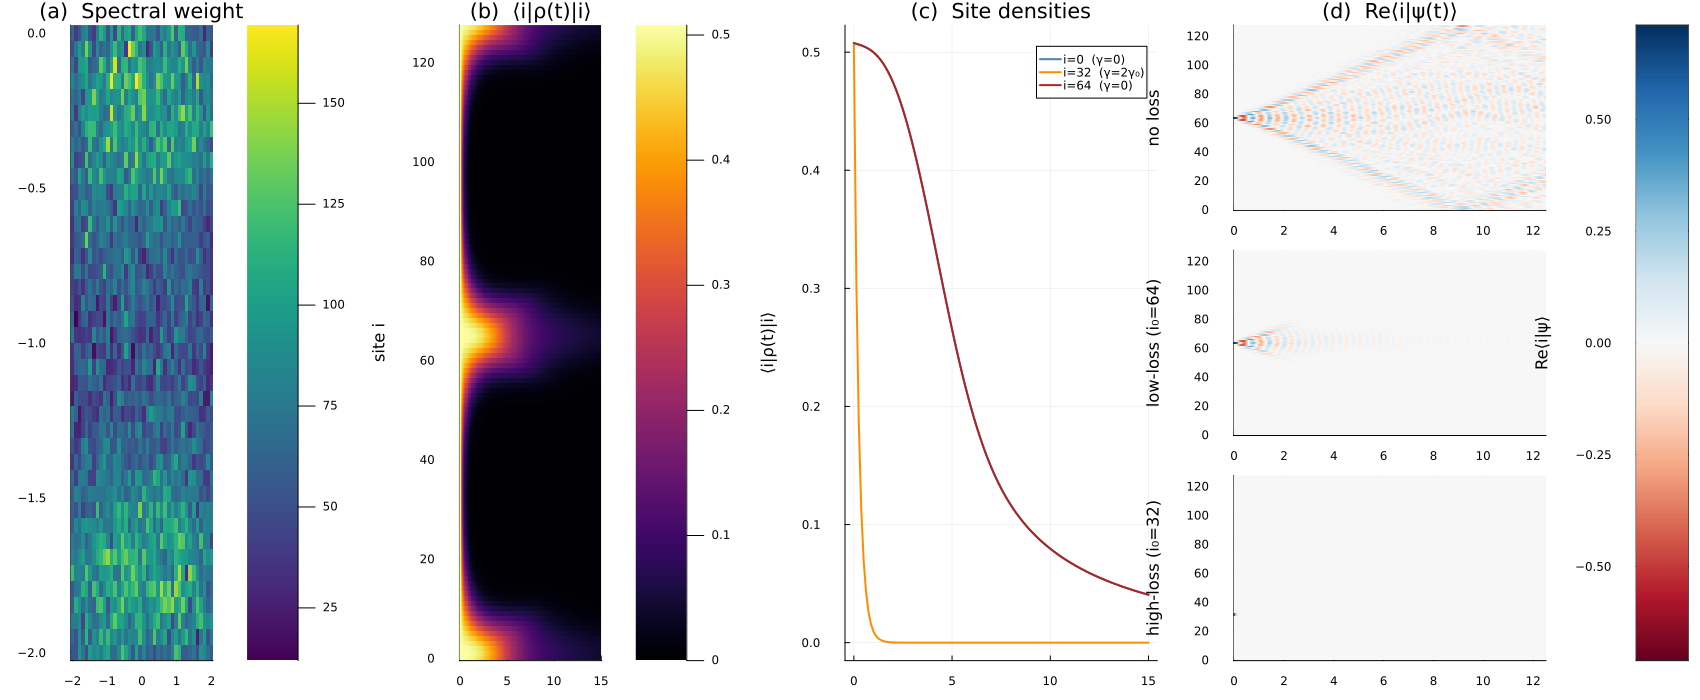

In [11]:
# Four-panel figure: (a) (b) (c) are single panels; (d) is three stacked heatmaps
# with a shared fake colorbar panel on the far right.
colors_pc = [:steelblue, :darkorange, :firebrick]

fig_a = heatmap(xgrid_pa, ygrid_pa, real.(Z_pa'),
    xlabel = "Re(z)", ylabel = "Im(z)",
    title  = "(a)  Spectral weight",
    color  = :viridis, colorbar = true)

fig_b = heatmap(times_pb, 0:N_p-1, density_pb,
    xlabel = "t", ylabel = "site i",
    title  = "(b)  ⟨i|ρ(t)|i⟩",
    color  = :inferno, colorbar = true)

sites_c  = [0, 32, 64]
labels_c = ["i=0  (γ=0)", "i=32  (γ=2γ₀)", "i=64  (γ=0)"]
fig_c = plot(times_pb, density_pb[sites_c[1]+1, :],
    label = labels_c[1], lw = 2, color = colors_pc[1],
    xlabel = "t", ylabel = "⟨i|ρ(t)|i⟩", title = "(c)  Site densities")
for k in 2:length(sites_c)
    plot!(fig_c, times_pb, density_pb[sites_c[k]+1, :],
        label = labels_c[k], lw = 2, color = colors_pc[k])
end

# (d) three stacked heatmaps — no individual colorbar
clims_d = (-cmax_pd, cmax_pd)
fig_d1 = heatmap(times_pd, 0:N_p-1, amp_pd_noloss,
    ylabel = "no loss", xlabel = "",
    color = :RdBu, clims = clims_d, colorbar = false, title = "(d)  Re⟨i|ψ(t)⟩")
fig_d2 = heatmap(times_pd, 0:N_p-1, amp_pd_lo,
    ylabel = "low-loss (i₀=64)", xlabel = "",
    color = :RdBu, clims = clims_d, colorbar = false, title = "")
fig_d3 = heatmap(times_pd, 0:N_p-1, amp_pd_hi,
    ylabel = "high-loss (i₀=32)", xlabel = "t",
    color = :RdBu, clims = clims_d, colorbar = false, title = "")

# Fake colorbar: thin vertical gradient strip spanning the full d-column height
n_cb = 200
cb_y = LinRange(clims_d[1], clims_d[2], n_cb)
Z_cb = repeat(cb_y, 1, 2)   # n_cb × 2, uniform across the strip width
fig_cb = heatmap([0, 1], cb_y, Z_cb;
    color = :RdBu, clims = clims_d, colorbar = false,
    xticks = nothing, framestyle = :box,
    ylabel = "Re⟨i|ψ⟩", title = "")

l = @layout [a b c [d1; d2; d3] e{0.04w}]
plot(fig_a, fig_b, fig_c, fig_d1, fig_d2, fig_d3, fig_cb,
    layout = l, size = (1700, 700))

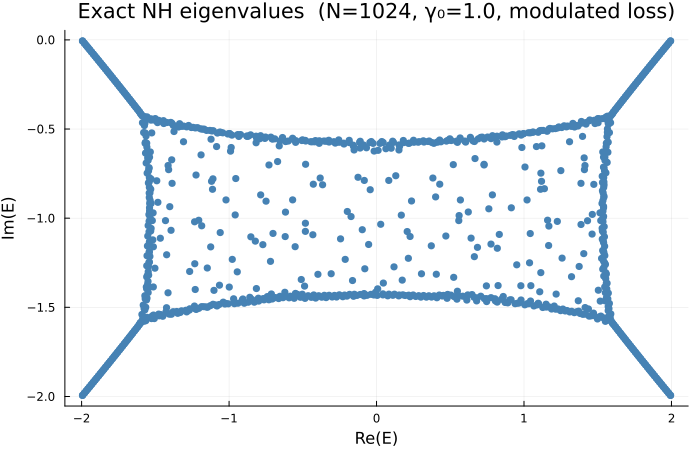

In [30]:
# Exact test: dense NH Hamiltonian with modulated loss, diagonalized exactly.
# H = H₀ - iΓ,  H₀ = 1D chain (PBC, t=1),  Γ[i,i] = γ₀(1 - cos(2·2πi/N))

N_ex  = 128*8
t_ex  = 1.0
γ0_ex = 1.0

H_ex = zeros(ComplexF64, N_ex, N_ex)
for i in 1:N_ex
    H_ex[i, mod(i,   N_ex) + 1] += t_ex   # hop right (PBC)
    H_ex[i, mod(i-2, N_ex) + 1] += t_ex   # hop left  (PBC)
    γi = γ0_ex - γ0_ex * cos(2 * 2π * (i-1) / N_ex)
    H_ex[i, i] -= 1im * γi
end

vals_ex = eigvals(H_ex)

scatter(real.(vals_ex), imag.(vals_ex),
    xlabel = "Re(E)", ylabel = "Im(E)",
    title  = "Exact NH eigenvalues  (N=$N_ex, γ₀=$γ0_ex, modulated loss)",
    marker = :circle, markersize = 4, markerstrokewidth = 0,
    legend = false, color = :steelblue,
    size = (700, 450))